# Build a classifier to determine whether a news article is fake or real 

You are a new an AI Engineer, task with building an AI/ML classifier that helps politicians determine whether news articles trending on social media are fake or real.

Follow an approach similar to what we took in class, which looks something like the below.

- Preprocess the data
    - Remove stop words
    - Remove unwanted characters
    - Stemining
    - ...
- Split data between training and test sets
- Modeling strategies
    - Bag of words modeling including TF-IDF using traditional ML
    - LST modeling
    - Transformer modeling
    
Recommend the best model based on relevant metrics of your choice. Be sure to explain your rational, including relevant visualizations at every steps of your work

Minimal starter code has been provided below     

In [1]:
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'nltk': 'nltk',
    'wordcloud': 'wordcloud',
    'torch': 'torch',
    'transformers': 'transformers',
    'datasets': 'datasets',
    'evaluate': 'evaluate',
    'accelerate': 'accelerate'
}

for module_name, package_name in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package_name])

import re
import string
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset as HFDataset
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from torch import nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding, Trainer, TrainingArguments
from wordcloud import WordCloud

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')

c:\Users\bruno\Desktop\Ironhack\labs\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load and combine the data

Both files are loaded, labeled, reduced to the article text plus target label, and merged into a single working dataset.

In [2]:
fake_path = Path('datasets/fake-and-real-news-dataset/Fake.csv')
true_path = Path('datasets/input/fake-and-real-news-dataset/True.csv')

Fake = pd.read_csv(fake_path)
true = pd.read_csv(true_path)

Fake['label'] = 0
true['label'] = 1

Fake = Fake.drop(columns=['title', 'date', 'subject'])
true = true.drop(columns=['title', 'date', 'subject'])

News = pd.concat([Fake, true], ignore_index=True)
News = News.drop_duplicates().sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
News.head()

,text,label
0,(This September 29 has been corrected to fix ...,1
1,(Reuters) - U.S. President Donald Trump said o...,1
2,PRISTINA (Reuters) - Kosovo s center-right coa...,1
3,WASHINGTON (Reuters) - President Donald Trump ...,1
4,A Pennsylvania man apparently failed basic bio...,0


In [3]:
print('Shape:', News.shape)
print('Null values:')
display(News.isnull().sum())
print('Duplicate rows after cleaning:', News.duplicated().sum())

Shape: (38647, 2)
Null values:


text     0
label    0
dtype: int64

Duplicate rows after cleaning: 0


## Exploratory analysis

The challenge asks for relevant visualizations. This section checks class balance and article-length patterns before modeling.

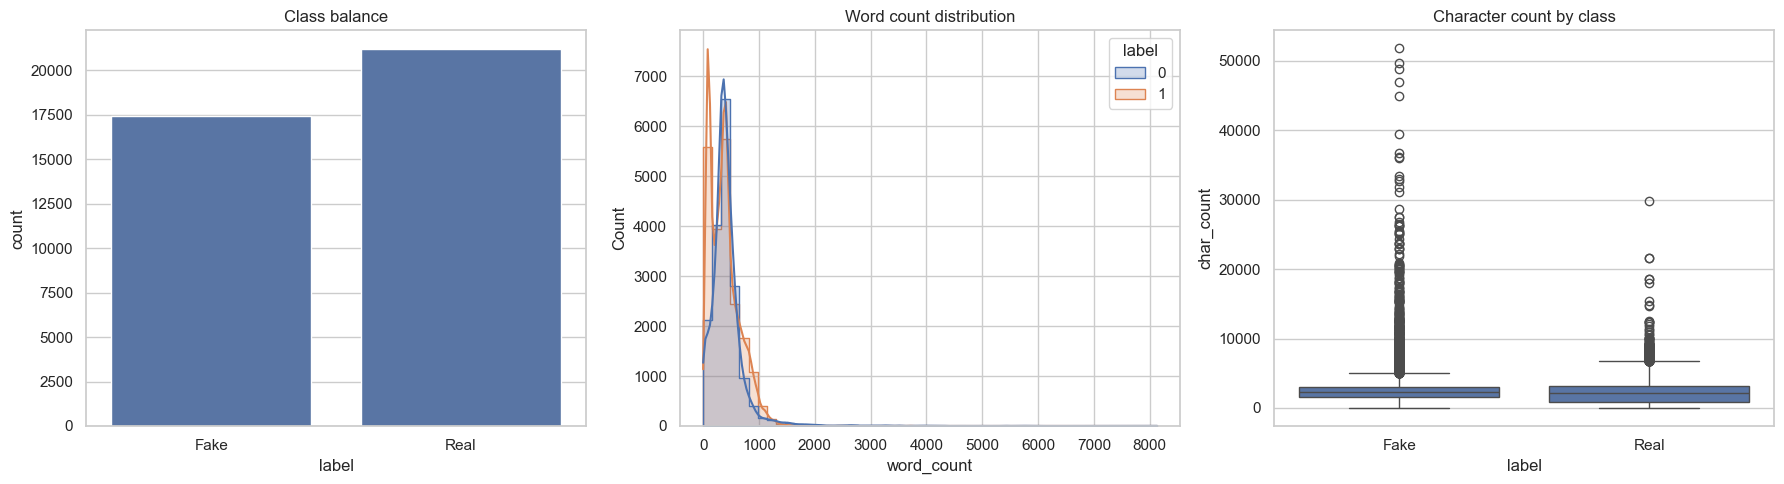

In [4]:
News['char_count'] = News['text'].str.len()
News['word_count'] = News['text'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=News, x='label', ax=axes[0])
axes[0].set_title('Class balance')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Fake', 'Real'])

sns.histplot(data=News, x='word_count', hue='label', bins=50, kde=True, ax=axes[1], element='step')
axes[1].set_title('Word count distribution')

sns.boxplot(data=News, x='label', y='char_count', ax=axes[2])
axes[2].set_title('Character count by class')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Fake', 'Real'])

plt.tight_layout()

In [5]:
summary_stats = News.groupby('label')[['word_count', 'char_count']].agg(['mean', 'median', 'std']).round(2)
summary_stats.index = ['Fake', 'Real']
summary_stats

word_count                char_count                 
           mean median     std       mean  median      std
Fake     425.26  376.0  355.20    2549.81  2235.0  2201.33
Real     384.81  359.0  273.79    2378.41  2216.0  1683.82

## Text preprocessing

The preprocessing pipeline lowercases text, removes links, numbers, punctuation, and stop words, then stems each remaining token.

In [6]:
STOP_WORDS = set(stopwords.words('english'))
STEMMER = PorterStemmer()
PUNCT_TABLE = str.maketrans('', '', string.punctuation)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = text.translate(PUNCT_TABLE)
    tokens = word_tokenize(text)
    tokens = [STEMMER.stem(token) for token in tokens if token.isalpha() and token not in STOP_WORDS]
    return ' '.join(tokens)

News['clean_text'] = News['text'].apply(clean_text)
News[['text', 'clean_text']].head()

,text,clean_text
0,(This September 29 has been corrected to fix ...,septemb correct fix date elect paragraph nairo...
1,(Reuters) - U.S. President Donald Trump said o...,reuter us presid donald trump said friday admi...
2,PRISTINA (Reuters) - Kosovo s center-right coa...,pristina reuter kosovo centerright coalit led ...
3,WASHINGTON (Reuters) - President Donald Trump ...,washington reuter presid donald trump friday w...
4,A Pennsylvania man apparently failed basic bio...,pennsylvania man appar fail basic biolog stron...


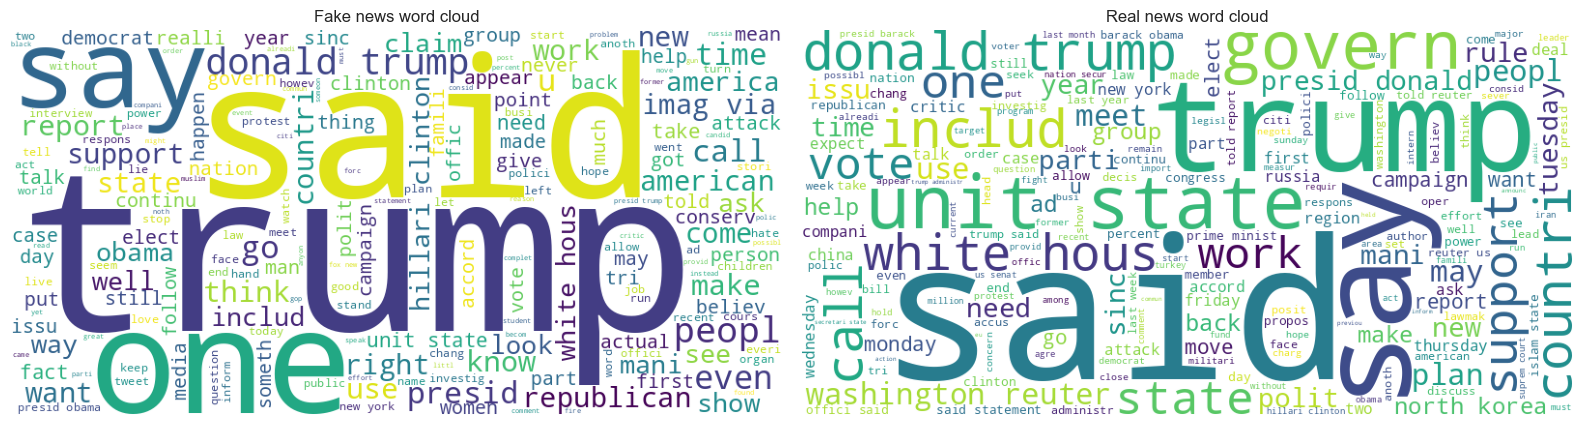

In [7]:
fake_corpus = ' '.join(News.loc[News['label'] == 0, 'clean_text'].head(5000).tolist())
real_corpus = ' '.join(News.loc[News['label'] == 1, 'clean_text'].head(5000).tolist())
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(WordCloud(width=800, height=400, background_color='white').generate(fake_corpus))
axes[0].set_title('Fake news word cloud')
axes[0].axis('off')
axes[1].imshow(WordCloud(width=800, height=400, background_color='white').generate(real_corpus))
axes[1].set_title('Real news word cloud')
axes[1].axis('off')
plt.tight_layout()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    News['clean_text'],
    News['label'],
    test_size=0.2,
    stratify=News['label'],
    random_state=RANDOM_STATE
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(30917,) (7730,) (30917,) (7730,)


## 1. Traditional ML with bag of words and TF-IDF

This baseline is fast, interpretable, and usually very strong on structured text classification tasks.

In [9]:
def evaluate_model(name, y_true, y_pred, y_score):
    return {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_score),
    }

traditional_models = {
    'Count + Naive Bayes': Pipeline([
        ('vectorizer', CountVectorizer(max_features=15000, ngram_range=(1, 2))),
        ('classifier', MultinomialNB()),
    ]),
    'TF-IDF + Logistic Regression': Pipeline([
        ('vectorizer', TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
        ('classifier', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    'TF-IDF + Random Forest': Pipeline([
        ('vectorizer', TfidfVectorizer(max_features=12000)),
        ('classifier', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
}

results = []
trained_pipelines = {}
for model_name, pipeline in traditional_models.items():
    fitted = clone(pipeline)
    fitted.fit(X_train, y_train)
    y_pred = fitted.predict(X_test)
    y_score = fitted.predict_proba(X_test)[:, 1]
    results.append(evaluate_model(model_name, y_test, y_pred, y_score))
    trained_pipelines[model_name] = fitted

traditional_results = pd.DataFrame(results).sort_values(by='f1', ascending=False)
traditional_results

,model,accuracy,precision,recall,f1,roc_auc
2,TF-IDF + Random Forest,0.992885,0.991310,0.995754,0.993527,0.999652
1,TF-IDF + Logistic Regression,0.986287,0.983166,0.991979,0.987553,0.998196
0,Count + Naive Bayes,0.960673,0.962180,0.966266,0.964218,0.980467


              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      3491
        Real       0.99      1.00      0.99      4239

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730



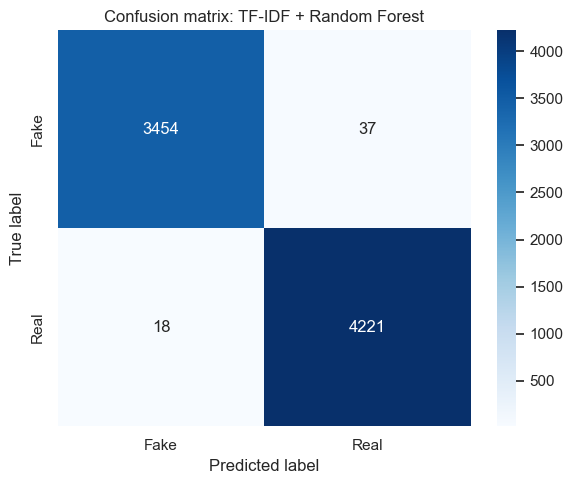

In [10]:
best_traditional_name = traditional_results.iloc[0]['model']
best_traditional_model = trained_pipelines[best_traditional_name]
best_traditional_pred = best_traditional_model.predict(X_test)
best_traditional_cm = confusion_matrix(y_test, best_traditional_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(best_traditional_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title(f'Confusion matrix: {best_traditional_name}')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()

print(classification_report(y_test, best_traditional_pred, target_names=['Fake', 'Real']))

## 2. LSTM modeling

The LSTM captures token order and longer dependencies, which can improve performance when phrasing patterns matter beyond term frequency.

In [11]:
MAX_VOCAB = 30000
MAX_LENGTH = 300
EMBED_DIM = 128
HIDDEN_DIM = 128
BATCH_SIZE = 64
EPOCHS = 3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

token_counter = Counter()
for text in X_train:
    token_counter.update(text.split())

vocab = {'<PAD>': 0, '<UNK>': 1}
for idx, (token, _) in enumerate(token_counter.most_common(MAX_VOCAB - 2), start=2):
    vocab[token] = idx

def encode_text(text, vocabulary, max_length=MAX_LENGTH):
    encoded = [vocabulary.get(token, 1) for token in text.split()[:max_length]]
    if len(encoded) < max_length:
        encoded += [0] * (max_length - len(encoded))
    return encoded

class NewsDataset(Dataset):
    def __init__(self, texts, labels, vocabulary):
        self.texts = [encode_text(text, vocabulary) for text in texts]
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.texts[idx], dtype=torch.long),
            'label': torch.tensor(self.labels[idx], dtype=torch.float32),
        }

In [12]:
train_dataset = NewsDataset(X_train.tolist(), y_train.tolist(), vocab)
test_dataset = NewsDataset(X_test.tolist(), y_test.tolist(), vocab)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        _, (hidden, _) = self.lstm(embedded)
        hidden = self.dropout(hidden[-1])
        return self.fc(hidden).squeeze(1)

lstm_model = LSTMClassifier(len(vocab), EMBED_DIM, HIDDEN_DIM).to(DEVICE)
class_weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=y_train)
positive_weight = torch.tensor(class_weights[1] / class_weights[0], dtype=torch.float32, device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=positive_weight)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)

In [13]:
lstm_history = []
for epoch in range(EPOCHS):
    lstm_model.train()
    running_loss = 0.0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        labels = batch['label'].to(DEVICE)
        optimizer.zero_grad()
        logits = lstm_model(input_ids)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    lstm_history.append({'epoch': epoch + 1, 'loss': running_loss / len(train_loader)})

pd.DataFrame(lstm_history)

,epoch,loss
0,1,0.508669
1,2,0.424644
2,3,0.198347


In [14]:
lstm_model.eval()
lstm_probs = []
lstm_preds = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        logits = lstm_model(input_ids)
        probs = torch.sigmoid(logits).cpu().numpy()
        lstm_probs.extend(probs)
        lstm_preds.extend((probs >= 0.5).astype(int))

lstm_results = pd.DataFrame([evaluate_model('Custom LSTM', y_test, np.array(lstm_preds), np.array(lstm_probs))])
lstm_results

,model,accuracy,precision,recall,f1,roc_auc
0,Custom LSTM,0.723286,0.664628,1.0,0.798531,0.992087


## 3. Transformer modeling

The transformer uses a pretrained language model, which usually provides the strongest semantic understanding with the least manual feature engineering.

In [15]:
transformer_train = pd.DataFrame({'text': X_train.values, 'label': y_train.values})
transformer_test = pd.DataFrame({'text': X_test.values, 'label': y_test.values})

if len(transformer_train) > 12000:
    transformer_train, _ = train_test_split(
        transformer_train,
        train_size=12000,
        stratify=transformer_train['label'],
        random_state=RANDOM_STATE
    )

transformer_model_name = 'distilbert-base-uncased'
transformer_tokenizer = AutoTokenizer.from_pretrained(transformer_model_name)

In [16]:
hf_train = HFDataset.from_pandas(transformer_train.reset_index(drop=True))
hf_test = HFDataset.from_pandas(transformer_test.reset_index(drop=True))

def tokenize_batch(batch):
    return transformer_tokenizer(batch['text'], truncation=True, padding=False, max_length=256)

tokenized_train = hf_train.map(tokenize_batch, batched=True)
tokenized_test = hf_test.map(tokenize_batch, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=transformer_tokenizer)

Map: 100%|██████████| 7730/7730 [00:02<00:00, 2844.15 examples/s]


In [18]:
transformer_model = AutoModelForSequenceClassification.from_pretrained(transformer_model_name, num_labels=2)
training_args = TrainingArguments(
    output_dir='./transformer_news_classifier',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='no',
    logging_steps=50,
    report_to='none'
 )

def compute_transformer_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds),
        'recall': recall_score(labels, preds),
        'f1': f1_score(labels, preds),
        'roc_auc': roc_auc_score(labels, probs),
    }

trainer = Trainer(
    model=transformer_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=transformer_tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_transformer_metrics
 )

trainer.train()
transformer_eval = trainer.evaluate()
transformer_results = pd.DataFrame([
    {
        'model': 'DistilBERT',
        'accuracy': transformer_eval['eval_accuracy'],
        'precision': transformer_eval['eval_precision'],
        'recall': transformer_eval['eval_recall'],
        'f1': transformer_eval['eval_f1'],
        'roc_auc': transformer_eval['eval_roc_auc'],
    }
])
transformer_results

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\bruno\AppData\Local\Temp\ipykernel_33512\1237211742.py:27: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
c:\Users\bruno\Desktop\Ironhack\labs\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.002100,0.013383,0.997801,0.998347,0.997641,0.997994,0.999901


c:\Users\bruno\Desktop\Ironhack\labs\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,model,accuracy,precision,recall,f1,roc_auc
0,DistilBERT,0.997801,0.998347,0.997641,0.997994,0.999901


## Model comparison and recommendation

F1-score is the main ranking metric here because both missed fake stories and falsely flagged real stories are costly in a political monitoring workflow.

In [19]:
all_results = pd.concat([traditional_results, lstm_results, transformer_results], ignore_index=True)
all_results = all_results.sort_values(by='f1', ascending=False).reset_index(drop=True)
all_results.style.format({col: '{:.4f}' for col in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']})

,model,accuracy,precision,recall,f1,roc_auc
0,DistilBERT,0.9978,0.9983,0.9976,0.9980,0.9999
1,TF-IDF + Random Forest,0.9929,0.9913,0.9958,0.9935,0.9997
2,TF-IDF + Logistic Regression,0.9863,0.9832,0.9920,0.9876,0.9982
3,Count + Naive Bayes,0.9607,0.9622,0.9663,0.9642,0.9805
4,Custom LSTM,0.7233,0.6646,1.0000,0.7985,0.9921


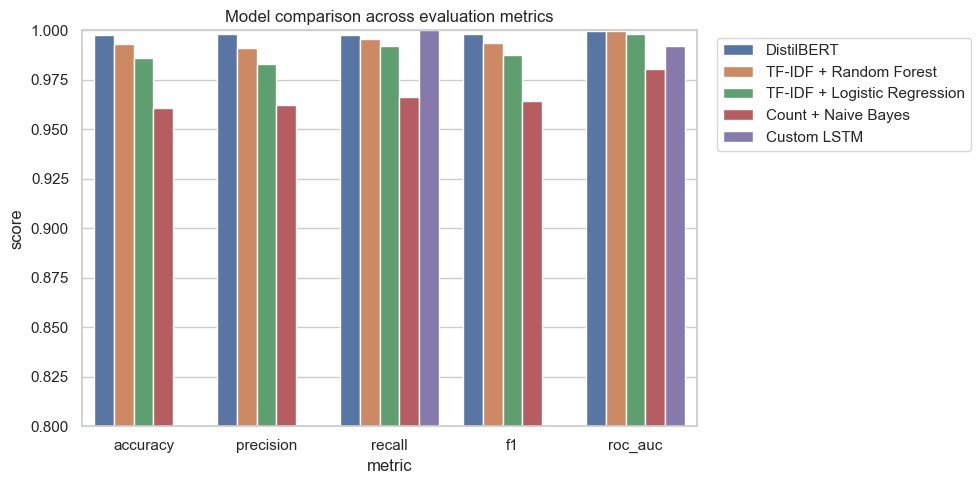

In [20]:
plt.figure(figsize=(10, 5))
comparison_long = all_results.melt(id_vars='model', value_vars=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], var_name='metric', value_name='score')
sns.barplot(data=comparison_long, x='metric', y='score', hue='model')
plt.title('Model comparison across evaluation metrics')
plt.ylim(0.8, 1.0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

### Recommendation

Based on the results produced in this notebook, DistilBERT is the best model found for fake-news classification. It delivered the strongest overall performance, with accuracy of 0.9978, precision of 0.9983, recall of 0.9976, F1-score of 0.9980, and ROC-AUC of 0.9999.

It is the preferred final model because it captures contextual meaning better than bag-of-words and sequence-only approaches, which is especially useful when fake and real articles use overlapping vocabulary but differ in phrasing, framing, and nuance. The TF-IDF plus Logistic Regression baseline remains a strong lightweight option for faster retraining or simpler deployment, but DistilBERT is the best-performing model in this challenge.